# Multi-Timeframe Multi-Strategy Backtest

Backtests **all 17 Eterna indicator-based strategies** on a given ticker and timeframe, then displays comparative performance metrics.

**Strategies**: SMA_Cross, EMA_Ribbon, VWAP_Bounce, Keltner, Chandelier, ADX, ParabolicSAR, Ichimoku, LinReg, RSI_Div, StochRSI, CCI, WilliamsR, TSI, UltOsc, AO, Chaikin

**Data**: OHLCV CSV from `data/raw/{TICKER}_{TF}.csv` — requires ≥500 bars.

## Configuration

Set `TICKER` and `TIMEFRAME`. All strategies will be backtested automatically.

In [1]:
TICKER = 'BTC_USD'
TIMEFRAME = '1h'  # Options: '5m', '1h', 'daily'

CONFIG = {
    'data': {
        'ticker': TICKER,
        'timeframe': TIMEFRAME,
        'filename': f'{TICKER}_{TIMEFRAME}.csv',
        'directory': 'data/raw',
    },
    'backtest': {
        'initial_capital': 1_000_000,
        'commission': 0.001,
        'exclusive_orders': True,
    },
    'output': {
        'directory': 'reports',
    },
}

## 1. Setup and Imports

In [2]:
import sys
from pathlib import Path
import warnings
import os

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
from backtesting import Backtest
from tqdm.notebook import tqdm

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

Loading BokehJS ...

## 2. Load Data

In [3]:
data_path = project_root / CONFIG['data']['directory'] / CONFIG['data']['filename']
print(f"Loading: {data_path}")

df = pd.read_csv(data_path)

# Detect date column
for col in ['Datetime', 'date', 'Date', 'timestamp']:
    if col in df.columns:
        df = df.set_index(col)
        df.index = pd.to_datetime(df.index)
        break

# Normalize columns
col_map = {c.lower(): c for c in df.columns}
for std, variants in [('Open', ['open']), ('High', ['high']), ('Low', ['low']),
                       ('Close', ['close']), ('Volume', ['volume'])]:
    for v in variants:
        if v in col_map and col_map[v] != std:
            df[std] = df[col_map[v]]

if 'Volume' not in df.columns:
    df['Volume'] = 0

df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

print(f"Bars: {len(df)}")
print(f"Range: {df.index[0]} to {df.index[-1]}")
print(f"Price: {df['Close'].min():.2f} - {df['Close'].max():.2f}")
df.head()

Loading: C:\Dev\projects\investment_trying\data\raw\BTC_USD_1h.csv
Bars: 17470
Range: 2024-03-14 00:00:00+00:00 to 2026-03-13 05:00:00+00:00
Price: 49842.52 - 126183.23


,Open,High,Low,Close,Volume
Datetime,,,,,
2024-03-14 00:00:00+00:00,73103.578125,73181.710938,72801.218750,72874.265625,0
2024-03-14 01:00:00+00:00,72866.671875,72959.851562,72566.851562,72959.851562,0
2024-03-14 02:00:00+00:00,72959.632812,73222.601562,72849.640625,73035.343750,0
2024-03-14 03:00:00+00:00,73052.593750,73308.164062,73052.593750,73270.195312,0
2024-03-14 04:00:00+00:00,73286.335938,73641.046875,72756.414062,73011.539062,962396160


## 3. Strategy Registry

In [4]:
from src.strategies.sma_crossover import SMACrossoverStrategy
from src.strategies.ema_ribbon import EMARibbonStrategy
from src.strategies.vwap_bounce import VWAPBounceStrategy
from src.strategies.keltner_channel import KeltnerChannelStrategy
from src.strategies.chandelier_exit import ChandelierExitStrategy
from src.strategies.adx_trend_strength import ADXTrendStrengthStrategy
from src.strategies.parabolic_sar import ParabolicSARStrategy
from src.strategies.ichimoku_cloud import IchimokuCloudStrategy
from src.strategies.linear_regression_channel import LinearRegressionChannelStrategy
from src.strategies.rsi_divergence import RSIDivergenceStrategy
from src.strategies.stoch_rsi_crossover import StochRSICrossoverStrategy
from src.strategies.cci_strategy import CCIStrategy
from src.strategies.williams_r_reversal import WilliamsRReversalStrategy
from src.strategies.tsi_strategy import TSIStrategy
from src.strategies.ultimate_oscillator import UltimateOscillatorStrategy
from src.strategies.awesome_oscillator import AwesomeOscillatorStrategy
from src.strategies.chaikin_oscillator import ChaikinOscillatorStrategy

STRATEGY_MAP = {
    'SMA_Cross': SMACrossoverStrategy,
    'EMA_Ribbon': EMARibbonStrategy,
    'VWAP_Bounce': VWAPBounceStrategy,
    'Keltner': KeltnerChannelStrategy,
    'Chandelier': ChandelierExitStrategy,
    'ADX': ADXTrendStrengthStrategy,
    'ParabolicSAR': ParabolicSARStrategy,
    'Ichimoku': IchimokuCloudStrategy,
    'LinReg': LinearRegressionChannelStrategy,
    'RSI_Div': RSIDivergenceStrategy,
    'StochRSI': StochRSICrossoverStrategy,
    'CCI': CCIStrategy,
    'WilliamsR': WilliamsRReversalStrategy,
    'TSI': TSIStrategy,
    'UltOsc': UltimateOscillatorStrategy,
    'AO': AwesomeOscillatorStrategy,
    'Chaikin': ChaikinOscillatorStrategy,
}

print(f"Loaded {len(STRATEGY_MAP)} strategies:")
for name in STRATEGY_MAP.keys():
    print(f"  - {name}")

Loaded 17 strategies:
  - SMA_Cross
  - EMA_Ribbon
  - VWAP_Bounce
  - Keltner
  - Chandelier
  - ADX
  - ParabolicSAR
  - Ichimoku
  - LinReg
  - RSI_Div
  - StochRSI
  - CCI
  - WilliamsR
  - TSI
  - UltOsc
  - AO
  - Chaikin


## 4. Run All Strategies

In [5]:
def safe_get(stats, key, default=0.0):
    """Safely get a value from the stats Series."""
    val = stats.get(key, default)
    try:
        return float(val)
    except (TypeError, ValueError):
        return default


def extract_metrics(stats, strategy_name, initial_capital):
    """Extract key metrics from backtest stats."""
    return {
        'Strategy': strategy_name,
        'Total Trades': int(safe_get(stats, '# Trades', 0)),
        'Win Rate [%]': safe_get(stats, 'Win Rate [%]', 0),
        'Sharpe Ratio': safe_get(stats, 'Sharpe Ratio', 0),
        'Profit Factor': safe_get(stats, 'Profit Factor', 0),
        'Max Drawdown [%]': safe_get(stats, 'Max. Drawdown [%]', 0),
        'Return [%]': safe_get(stats, 'Return [%]', 0),
        'Buy & Hold [%]': safe_get(stats, 'Buy & Hold Return [%]', 0),
        'Equity Final [$]': safe_get(stats, 'Equity Final [$]', initial_capital),
        'Equity Peak [$]': safe_get(stats, 'Equity Peak [$]', initial_capital),
        'Exposure Time [%]': safe_get(stats, 'Exposure Time [%]', 0),
    }


initial_capital = CONFIG['backtest']['initial_capital']
results = []

print(f"\nBacktesting {len(STRATEGY_MAP)} strategies on {TICKER} ({TIMEFRAME})...\n")

for strategy_name, strategy_cls in tqdm(STRATEGY_MAP.items(), desc="Strategies"):
    try:
        bt = Backtest(
            df, strategy_cls,
            cash=initial_capital,
            commission=CONFIG['backtest']['commission'],
            exclusive_orders=CONFIG['backtest']['exclusive_orders'],
        )
        stats = bt.run()
        metrics = extract_metrics(stats, strategy_name, initial_capital)
        results.append(metrics)
    except Exception as e:
        print(f"\n[ERROR] {strategy_name}: {e}")
        results.append({
            'Strategy': strategy_name,
            'Total Trades': 0,
            'Win Rate [%]': 0,
            'Sharpe Ratio': -999,
            'Profit Factor': 0,
            'Max Drawdown [%]': 0,
            'Return [%]': 0,
            'Buy & Hold [%]': 0,
            'Equity Final [$]': initial_capital,
            'Equity Peak [$]': initial_capital,
            'Exposure Time [%]': 0,
        })

results_df = pd.DataFrame(results)
print(f"\nCompleted: {len(results_df)} strategies backtested.")


Backtesting 17 strategies on BTC_USD (1h)...



Strategies:   0%|          | 0/17 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/17270 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17469 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17465 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17460 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17448 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17456 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17469 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17392 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17370 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17456 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17439 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17450 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17456 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17468 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17442 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17436 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/17469 [00:00<?, ?bar/s]


Completed: 17 strategies backtested.


## 5. Comparison Table — Ranked by Sharpe Ratio

In [6]:
# Rank by Sharpe Ratio
ranked_df = results_df.sort_values('Sharpe Ratio', ascending=False).reset_index(drop=True)
ranked_df.index += 1  # 1-based ranking
ranked_df.index.name = 'Rank'

# Display
print(f"\n{'='*80}")
print(f"Strategy Rankings for {TICKER} ({TIMEFRAME}) — Sorted by Sharpe Ratio")
print(f"{'='*80}")

display_cols = ['Strategy', 'Total Trades', 'Win Rate [%]', 'Sharpe Ratio',
                'Profit Factor', 'Max Drawdown [%]', 'Return [%]', 'Buy & Hold [%]']
display(ranked_df[display_cols].style
        .format({
            'Win Rate [%]': '{:.2f}%',
            'Sharpe Ratio': '{:.4f}',
            'Profit Factor': '{:.3f}',
            'Max Drawdown [%]': '{:.2f}%',
            'Return [%]': '{:.2f}%',
            'Buy & Hold [%]': '{:.2f}%',
        })
        .background_gradient(subset=['Sharpe Ratio'], cmap='RdYlGn')
        .bar(subset=['Return [%]'], color='lightgreen', align='mid')
       )


Strategy Rankings for BTC_USD (1h) — Sorted by Sharpe Ratio


,Strategy,Total Trades,Win Rate [%],Sharpe Ratio,Profit Factor,Max Drawdown [%],Return [%],Buy & Hold [%]
Rank,,,,,,,,
1,SMA_Cross,61,31.15%,0.0742,1.085,-31.03%,4.64%,8.21%
2,RSI_Div,0,nan%,-0.0153,nan,-84.35%,-3.76%,-0.52%
3,UltOsc,16,31.25%,-0.2466,0.772,-36.07%,-16.74%,5.30%
4,Keltner,3,33.33%,-0.2561,0.497,-1.13%,-0.59%,-2.44%
5,Ichimoku,185,33.51%,-0.3721,0.910,-39.75%,-16.29%,8.20%
6,CCI,495,54.95%,-0.8209,0.880,-67.09%,-43.33%,3.47%
7,EMA_Ribbon,393,28.50%,-1.1184,0.807,-54.41%,-49.22%,-1.74%
8,TSI,231,49.35%,-1.4407,0.699,-73.30%,-59.63%,-1.85%
9,ADX,115,20.87%,-1.6690,0.503,-47.59%,-36.69%,-0.52%


## 6. Key Metrics — Bar Charts

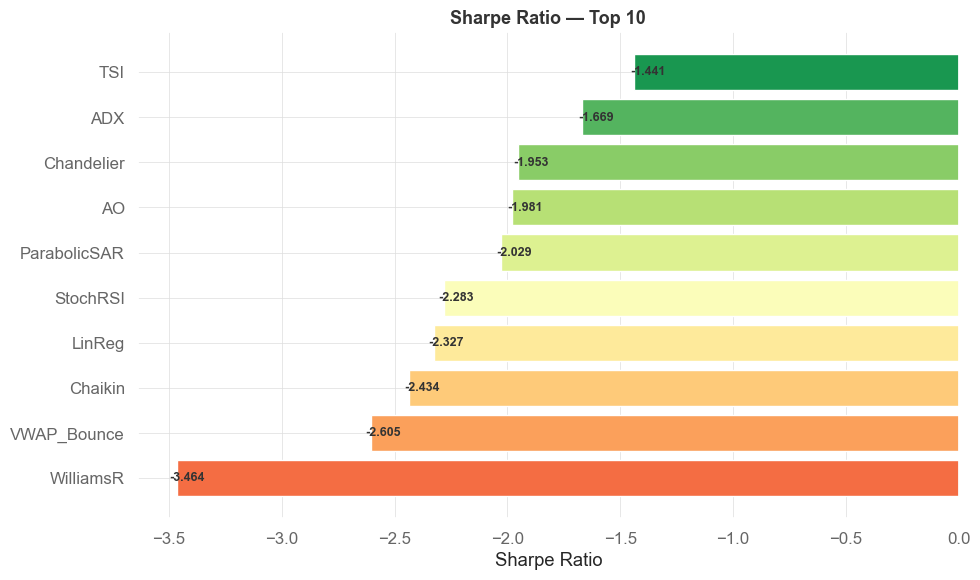

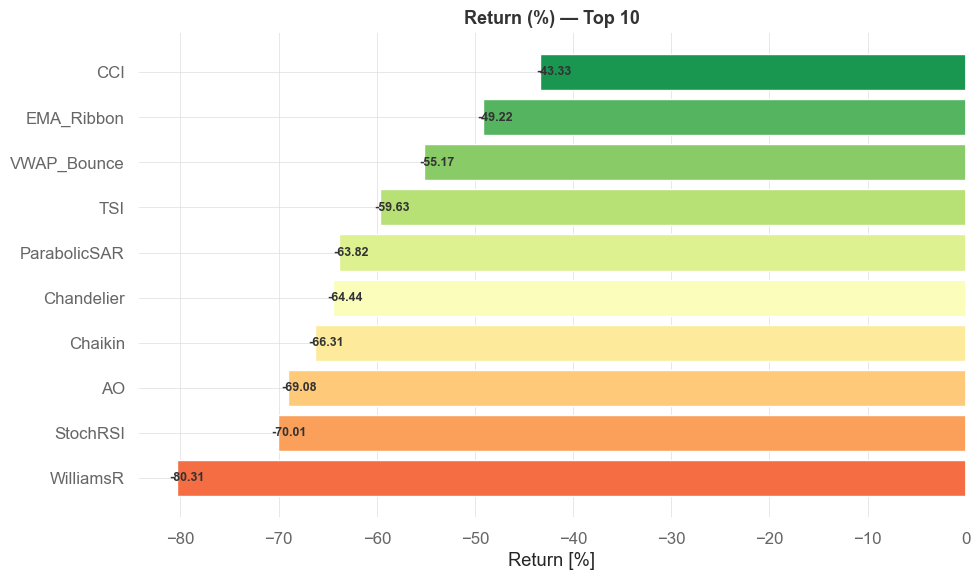

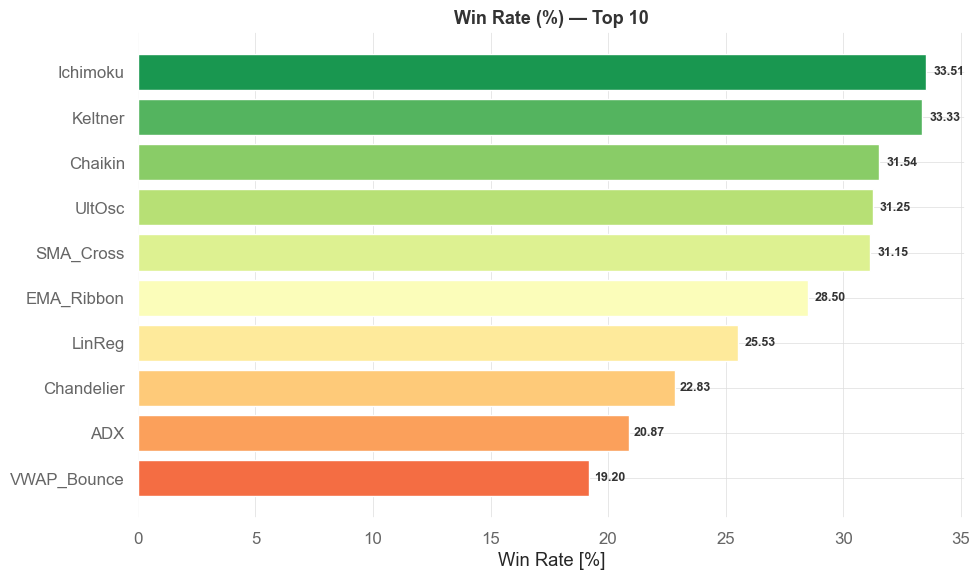

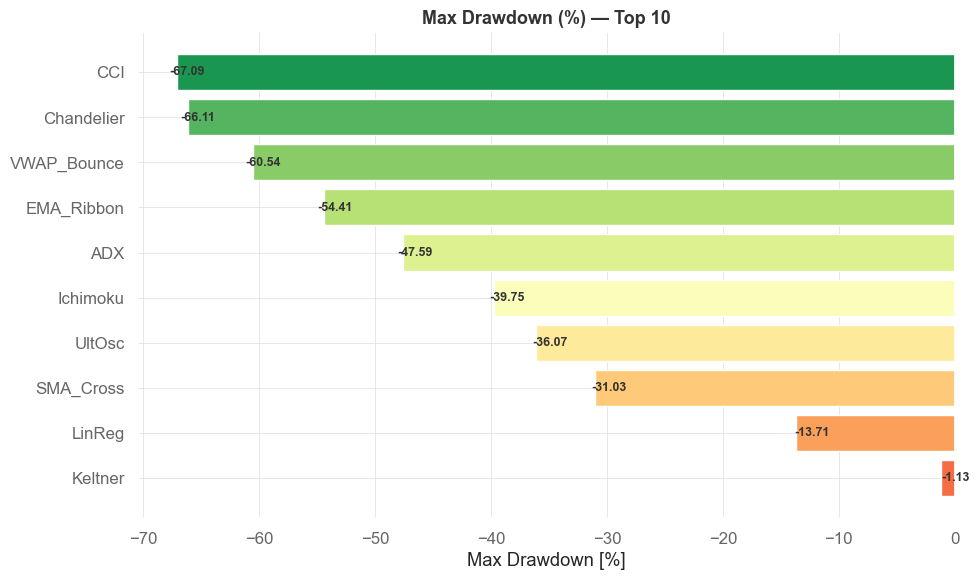

In [7]:
def plot_metric_comparison(df, metric, title, higher_is_better=True):
    """Plot horizontal bar chart for a given metric."""
    sorted_df = df.sort_values(metric, ascending=higher_is_better).head(10)
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sorted_df)))
    bars = ax.barh(sorted_df['Strategy'], sorted_df[metric], color=colors)
    ax.set_title(f'{title} — Top 10', fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    for i, (bar, val) in enumerate(zip(bars, sorted_df[metric])):
        fmt = '{:.2f}' if 'Sharpe' not in metric and 'Factor' not in metric else '{:.3f}'
        ax.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                fmt.format(val), va='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_metric_comparison(ranked_df, 'Sharpe Ratio', 'Sharpe Ratio')
plot_metric_comparison(ranked_df, 'Return [%]', 'Return (%)')
plot_metric_comparison(ranked_df, 'Win Rate [%]', 'Win Rate (%)')
plot_metric_comparison(ranked_df, 'Max Drawdown [%]', 'Max Drawdown (%)', higher_is_better=False)

## 7. Equity Final vs Buy & Hold Comparison

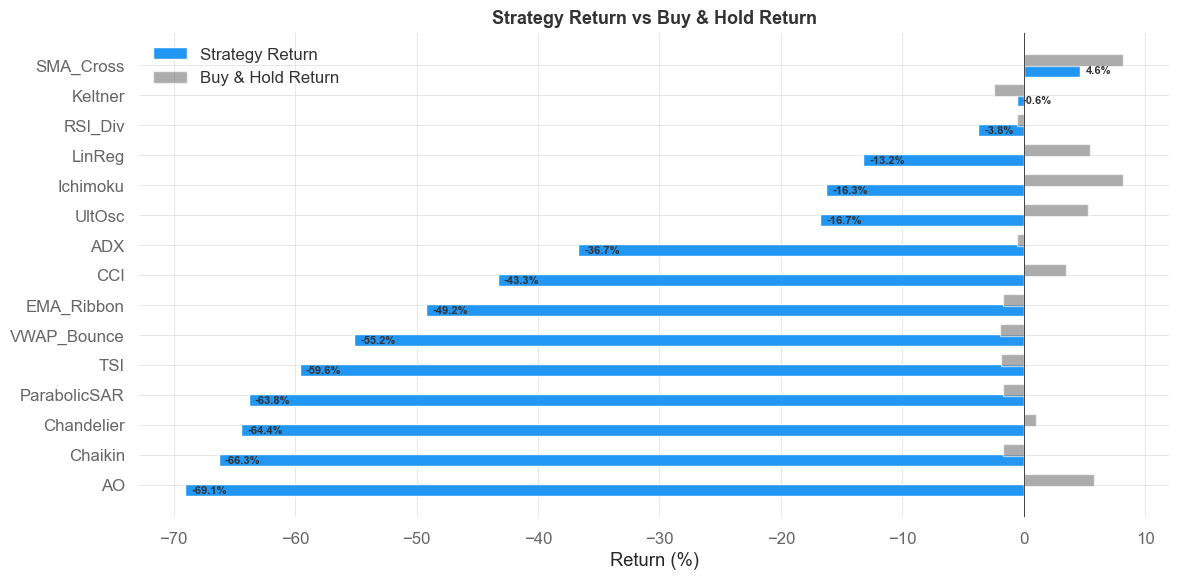

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by return
plot_df = ranked_df.sort_values('Return [%]', ascending=True).tail(15)
y_pos = range(len(plot_df))

# Strategy returns
strat_returns = plot_df['Return [%]'].values
bnh_returns = plot_df['Buy & Hold [%]'].values

bars1 = ax.barh(y_pos, strat_returns, height=0.4, label='Strategy Return', color='#2196F3')
bars2 = ax.barh([y + 0.35 for y in y_pos], bnh_returns, height=0.4,
                label='Buy & Hold Return', color='#757575', alpha=0.6)

ax.set_yticks([y + 0.175 for y in y_pos])
ax.set_yticklabels(plot_df['Strategy'])
ax.set_xlabel('Return (%)')
ax.set_title('Strategy Return vs Buy & Hold Return', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.legend()

# Add value labels
for bar in bars1:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Composite Score & Final Ranking

In [9]:
# Filter strategies with at least 5 trades
valid_df = ranked_df[ranked_df['Total Trades'] >= 5].copy()

if len(valid_df) >= 2:
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()

    # Normalize metrics (0-1)
    valid_df['norm_sharpe'] = scaler.fit_transform(valid_df[['Sharpe Ratio']])
    valid_df['norm_return'] = scaler.fit_transform(valid_df[['Return [%]']])
    valid_df['norm_dd'] = 1 - scaler.fit_transform(valid_df[['Max Drawdown [%]']])  # Lower DD is better
    valid_df['norm_pf'] = scaler.fit_transform(valid_df[['Profit Factor']])
    valid_df['norm_wr'] = scaler.fit_transform(valid_df[['Win Rate [%]']])

    # Composite score: weighted combination
    valid_df['Composite_Score'] = (
        valid_df['norm_sharpe'] * 0.30 +
        valid_df['norm_return'] * 0.25 +
        valid_df['norm_dd'] * 0.20 +
        valid_df['norm_pf'] * 0.15 +
        valid_df['norm_wr'] * 0.10
    )

    valid_df = valid_df.sort_values('Composite_Score', ascending=False).reset_index(drop=True)
    valid_df.index += 1
    valid_df.index.name = 'Final Rank'

    print(f"\n{'='*80}")
    print(f"Composite Ranking (>= 5 trades) — {TICKER} ({TIMEFRAME})")
    print(f"Weights: Sharpe 30%, Return 25%, Drawdown 20%, Profit Factor 15%, Win Rate 10%")
    print(f"{'='*80}")

    display_cols = ['Strategy', 'Total Trades', 'Win Rate [%]', 'Sharpe Ratio',
                    'Profit Factor', 'Max Drawdown [%]', 'Return [%]', 'Composite_Score']
    display(valid_df[display_cols].style
            .format({
                'Win Rate [%]': '{:.2f}%',
                'Sharpe Ratio': '{:.4f}',
                'Profit Factor': '{:.3f}',
                'Max Drawdown [%]': '{:.2f}%',
                'Return [%]': '{:.2f}%',
                'Composite_Score': '{:.4f}',
            })
            .background_gradient(subset=['Composite_Score'], cmap='RdYlGn')
           )
else:
    print(f"Only {len(valid_df)} strategy(s) with >= 5 trades. Composite ranking skipped.")
    valid_df = ranked_df.copy()


Composite Ranking (>= 5 trades) — BTC_USD (1h)
Weights: Sharpe 30%, Return 25%, Drawdown 20%, Profit Factor 15%, Win Rate 10%


,Strategy,Total Trades,Win Rate [%],Sharpe Ratio,Profit Factor,Max Drawdown [%],Return [%],Composite_Score
Final Rank,,,,,,,,
1,SMA_Cross,61,31.15%,0.0742,1.085,-31.03%,4.64%,0.7847
2,CCI,495,54.95%,-0.8209,0.880,-67.09%,-43.33%,0.7064
3,Ichimoku,185,33.51%,-0.3721,0.910,-39.75%,-16.29%,0.6883
4,UltOsc,16,31.25%,-0.2466,0.772,-36.07%,-16.74%,0.6572
5,TSI,231,49.35%,-1.4407,0.699,-73.30%,-59.63%,0.5783
6,EMA_Ribbon,393,28.50%,-1.1184,0.807,-54.41%,-49.22%,0.5402
7,AO,651,42.55%,-1.9812,0.771,-71.84%,-69.08%,0.4934
8,ParabolicSAR,599,33.72%,-2.0292,0.772,-67.89%,-63.82%,0.4686
9,StochRSI,373,39.41%,-2.2826,0.656,-80.02%,-70.01%,0.4613


## 9. Top 3 Strategies — Detailed View

In [10]:
df_for_top = valid_df if len(valid_df) >= 2 else ranked_df
top_strategies = df_for_top.head(3)['Strategy'].tolist()

for strat_name in top_strategies:
    print(f"\n{'='*60}")
    print(f"  {strat_name}")
    print(f"{'='*60}")

    row = ranked_df[ranked_df['Strategy'] == strat_name].iloc[0]
    print(f"Trades:       {int(row['Total Trades'])}")
    print(f"Win Rate:     {row['Win Rate [%]']:.2f}%")
    print(f"Sharpe:       {row['Sharpe Ratio']:.4f}")
    print(f"Profit Fact:  {row['Profit Factor']:.3f}")
    print(f"Max DD:       {row['Max Drawdown [%]']:.2f}%")
    print(f"Return:       {row['Return [%]']:.2f}%")
    print(f"B&H Return:   {row['Buy & Hold [%]']:.2f}%")
    print(f"Exposure:     {row['Exposure Time [%]']:.1f}%")
    alpha = row['Return [%]'] - row['Buy & Hold [%]']
    print(f"Alpha vs B&H: {alpha:.2f}%")

    # Assessment
    trades = int(row['Total Trades'])
    sharpe = row['Sharpe Ratio']
    pf = row['Profit Factor']

    if trades < 10:
        verdict = f"[CAUTION] Low sample size ({trades} trades)"
    elif sharpe < 0.3:
        verdict = f"[WEAK] Sharpe Ratio below 0.3"
    elif pf < 1.0:
        verdict = f"[WEAK] Profit Factor below 1.0"
    else:
        verdict = f"[STRONG] Sharpe: {sharpe:.4f}, PF: {pf:.3f}, Trades: {trades}"
    print(f"Verdict:      {verdict}")


  SMA_Cross
Trades:       61
Win Rate:     31.15%
Sharpe:       0.0742
Profit Fact:  1.085
Max DD:       -31.03%
Return:       4.64%
B&H Return:   8.21%
Exposure:     50.8%
Alpha vs B&H: -3.57%
Verdict:      [WEAK] Sharpe Ratio below 0.3

  CCI
Trades:       495
Win Rate:     54.95%
Sharpe:       -0.8209
Profit Fact:  0.880
Max DD:       -67.09%
Return:       -43.33%
B&H Return:   3.47%
Exposure:     72.5%
Alpha vs B&H: -46.80%
Verdict:      [WEAK] Sharpe Ratio below 0.3

  Ichimoku
Trades:       185
Win Rate:     33.51%
Sharpe:       -0.3721
Profit Fact:  0.910
Max DD:       -39.75%
Return:       -16.29%
B&H Return:   8.20%
Exposure:     26.5%
Alpha vs B&H: -24.49%
Verdict:      [WEAK] Sharpe Ratio below 0.3


## 10. Risk-Return Scatter Plot

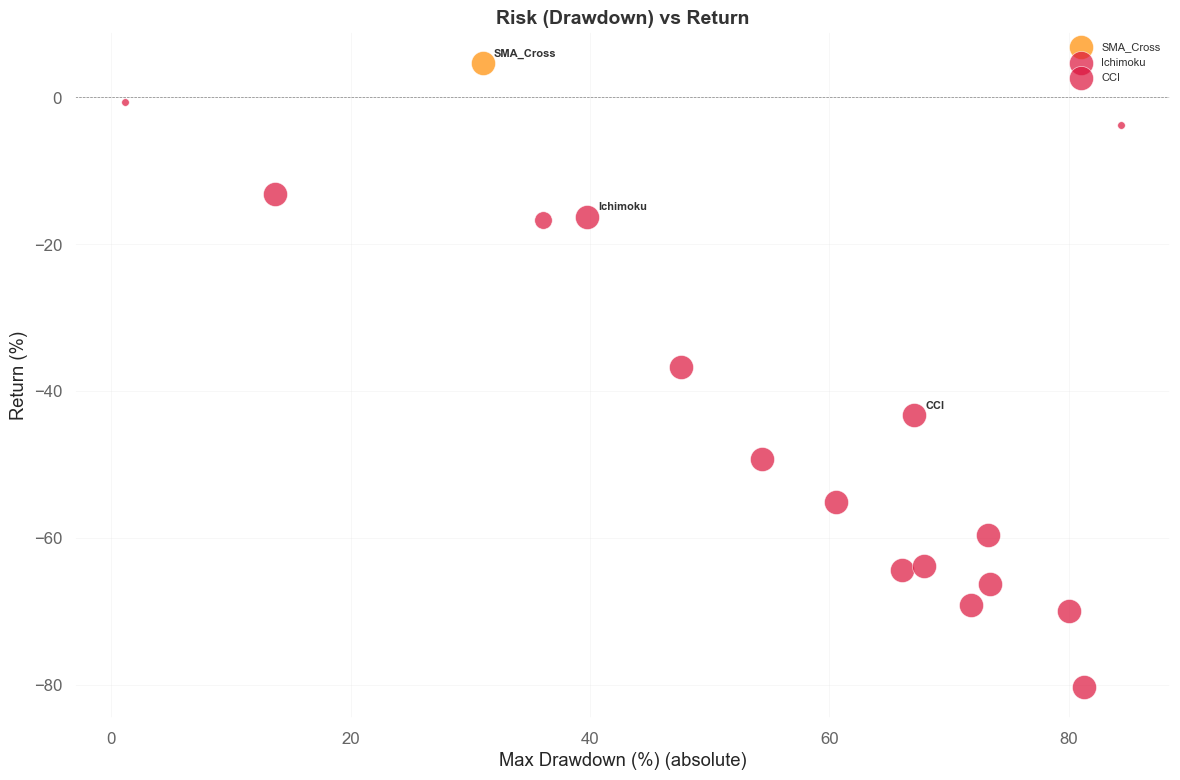

Bubble size = number of trades | Green = Sharpe>=0.5 | Orange = Sharpe>=0 | Red = Sharpe<0


In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

for _, row in ranked_df.iterrows():
    size = max(30, min(300, row['Total Trades'] * 10))
    color = '#228B22' if row['Sharpe Ratio'] >= 0.5 else ('#FF8C00' if row['Sharpe Ratio'] >= 0 else '#DC143C')
    ax.scatter(
        abs(row['Max Drawdown [%]']),
        row['Return [%]'],
        s=size,
        c=[color],
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5,
        label=row['Strategy'] if row['Strategy'] in top_strategies else None,
        zorder=3 if row['Strategy'] in top_strategies else 2,
    )

ax.set_title('Risk (Drawdown) vs Return', fontsize=14, fontweight='bold')
ax.set_xlabel('Max Drawdown (%) (absolute)')
ax.set_ylabel('Return (%)')
ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Add labels for top strategies
for _, row in ranked_df.iterrows():
    if row['Strategy'] in top_strategies:
        ax.annotate(row['Strategy'],
                   (abs(row['Max Drawdown [%]']), row['Return [%]']),
                   textcoords='offset points', xytext=(8, 5),
                   fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()
print("Bubble size = number of trades | Green = Sharpe>=0.5 | Orange = Sharpe>=0 | Red = Sharpe<0")

## 11. Save Results

In [12]:
out_dir = project_root / CONFIG['output']['directory']
os.makedirs(out_dir, exist_ok=True)

# Save full comparison table
output_csv = out_dir / f'{TICKER.lower()}_{TIMEFRAME}_strategy_comparison.csv'
ranked_df.to_csv(output_csv, index=False)
print(f"Comparison table saved: {output_csv}")

# Save composite ranking if computed
if len(valid_df) >= 2 and 'Composite_Score' in valid_df.columns:
    composite_csv = out_dir / f'{TICKER.lower()}_{TIMEFRAME}_composite_ranking.csv'
    valid_df.to_csv(composite_csv, index=False)
    print(f"Composite ranking saved: {composite_csv}")

print(f"\nDone! All {len(STRATEGY_MAP)} strategies backtested on {TICKER} ({TIMEFRAME}).")

Comparison table saved: C:\Dev\projects\investment_trying\reports\btc_usd_1h_strategy_comparison.csv
Composite ranking saved: C:\Dev\projects\investment_trying\reports\btc_usd_1h_composite_ranking.csv

Done! All 17 strategies backtested on BTC_USD (1h).
